# Ticari Orta Faz 1 - Execution Simulation

End-to-end exercise of the production pipeline against Oracle (no synthetic data, no notebook-local logic). Each section is self-contained: run the cells top to bottom or re-run a single block whenever needed.

**Sections at a glance**

- 1 / 1A : native table health and raw field distributions
- 2 / 2A : materialization into the derived feature table (42 columns)
- 3 / 3A / 3B : development, window split review, robustness comparisons
- 4 / 4A : supervised evaluation and weight tuning metrics
- 5 / 5A : promote + single / date-range scoring and label lift
- 6 / 6A : per-run monitoring bundle (score summary, band share)
- 7A : cross-run trend from the Oracle monitor history table
- 7 : operational notes

**How to read the outputs overall**

- Tables print the most important health metrics; wider payloads stay in `runtime/runs/<run_id>/`
- Plots focus on drift / share / shape changes across snapshots; colors match alert bands where relevant
- Oracle objects referenced here: `EWS_TO_FAZ1_NATIVE`, `EWS_TO_FAZ1_INPUT`, `EWS_TO_FAZ1_RESULTS`, `EWS_TO_FAZ1_DETAILS`, `EWS_TO_FAZ1_FEATURE_EFFECTS`, `EWS_TO_FAZ1_MONITOR_HISTORY`, `EWS_TO_FAZ1_OUTCOMES`

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "engine").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from engine.config_loader import load_config, load_secrets
from engine.lifecycle import LifecycleManager
from engine.materialization import NativeMaterializer
from engine.oracle_io import OracleConnector

plt.style.use("default")

config = load_config()
secrets = load_secrets()
manager = LifecycleManager()
materializer = NativeMaterializer(config, secrets)


In [2]:
def compact_dict(payload):
    if not isinstance(payload, dict):
        return payload
    return {key: value for key, value in payload.items() if key != "frame"}

def safe_run(label, fn, *args, **kwargs):
    try:
        result = fn(*args, **kwargs)
        print(f"{label}: OK")
        return result
    except Exception as exc:
        print(f"{label}: FAILED -> {exc}")
        return {"error": str(exc)}

def load_json_payload(path_value):
    if not path_value:
        return None
    path = Path(path_value)
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))

def compute_top_percent_metrics(frame, score_column, label_column, top_percent):
    ordered = frame[[score_column, label_column]].dropna().sort_values(score_column, ascending=False).reset_index(drop=True)
    if ordered.empty:
        return {}
    top_n = max(1, int(np.ceil(len(ordered) * top_percent)))
    ordered["pred_top"] = 0
    ordered.loc[: top_n - 1, "pred_top"] = 1
    y_true = ordered[label_column].astype(int)
    y_pred = ordered["pred_top"].astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "rows": int(len(ordered)),
        "top_n": int(top_n),
        "positive_rows": int(y_true.sum()),
        "baseline_rate": float(y_true.mean()),
        "precision_at_top_percent": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_at_top_percent": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_at_top_percent": float(f1_score(y_true, y_pred, zero_division=0)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

def flatten_outcome_metrics(metrics_payload):
    rows = []
    if not isinstance(metrics_payload, dict):
        return pd.DataFrame()
    primary = metrics_payload.get("primary")
    if isinstance(primary, dict):
        row = {"metric_group": "primary", **primary}
        rows.append(row)
    for key, payload in (metrics_payload.get("monitoring") or {}).items():
        if isinstance(payload, dict):
            rows.append({"metric_group": key, **payload})
    return pd.DataFrame(rows)

def draw_metric_bar(frame, *, category_column, value_columns, title):
    if frame.empty:
        print(f"{title}: veri yok")
        return
    ax = frame.set_index(category_column)[value_columns].plot(kind="bar", figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel("value")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def resolve_runtime_context(config, secrets):
    segment_value = config["development"]["segment_value"]
    snapshot_cfg = config["live_scoring"]["snapshot"]
    with OracleConnector(config, secrets) as ora:
        native_table = ora._qualified_table_name("native_features")
        snapshot_rows = ora._read_query(
            f"""
            SELECT DISTINCT TRUNC(SNAPSHOT_DATE) AS snapshot_date
            FROM {native_table}
            WHERE SEGMENT = :segment_value
            ORDER BY TRUNC(SNAPSHOT_DATE)
            """,
            {"segment_value": segment_value},
        )
    if snapshot_rows.empty:
        raise ValueError(
            "Native tabloda secilen segment icin snapshot bulunamadi. Once native tabloyu beslemelisin."
        )
    snapshot_values = pd.to_datetime(snapshot_rows["snapshot_date"]).sort_values().tolist()
    single_snapshot = snapshot_cfg.get("explicit_date") or pd.Timestamp(snapshot_values[-1]).date().isoformat()
    if snapshot_cfg.get("start_date") and snapshot_cfg.get("end_date"):
        range_start = snapshot_cfg["start_date"]
        range_end = snapshot_cfg["end_date"]
    else:
        tail_values = snapshot_values[-4:] if len(snapshot_values) >= 4 else snapshot_values
        range_start = pd.Timestamp(tail_values[0]).date().isoformat()
        range_end = pd.Timestamp(tail_values[-1]).date().isoformat()
    return {
        "pipeline_name": config["pipeline"]["name"],
        "segment": segment_value,
        "native_source": config["sources"]["native_features"]["oracle"]["table"],
        "derived_source": config["sources"]["input_features"]["oracle"]["table"],
        "outcomes_source": config["sources"]["outcomes"]["oracle"]["table"],
        "score_live_selector": snapshot_cfg["selector"],
        "single_snapshot": single_snapshot,
        "range_start": range_start,
        "range_end": range_end,
        "materialization_enabled": config["materialization"]["enabled"],
        "warmup_snapshots": config["materialization"]["trim_warmup_snapshots"],
    }

runtime_context = resolve_runtime_context(config, secrets)
SEGMENT = runtime_context["segment"]
SINGLE_SNAPSHOT = runtime_context["single_snapshot"]
RANGE_START = runtime_context["range_start"]
RANGE_END = runtime_context["range_end"]
TARGET_COLUMN = config["weight_optimization"]["target_column"]
TOP_PERCENT = float(config["weight_optimization"]["top_percent"])

overview = {
    **runtime_context,
}
display(pd.DataFrame([overview]))


,pipeline_name,segment,native_source,derived_source,outcomes_source,score_live_selector,single_snapshot,range_start,range_end,materialization_enabled,warmup_snapshots
0,ews_anomaly_detection,TICARI_ORTA,native_features,input_features,outcomes,previous_month_end,2026-04-30,2026-01-31,2026-04-30,True,18


## 1. Native Data Checks

**What it does**
Reads `EWS_TO_FAZ1_NATIVE` for the configured Faz 1 segment, prints an overview of snapshot coverage, customer count and row count, and shows 5 sample rows.

**How to read the output**

- `min_snapshot_date` / `max_snapshot_date` should match the business cadence (monthly, month-end). A gap means the upstream ETL missed a month.
- `row_count` should be roughly `customer_count * snapshots`; a large drop means customers dropped out of the cohort.
- `customer_count` reflects unique `CUSTOMER_ID` values. If the number shrinks over time compared with earlier runs, the segment filter may have tightened.
- The sample rows should contain all 23 native columns with realistic values; NULLs in critical columns (`fs_net_sales_cumulative`, `pos_monthly_volume`) mean the ETL is incomplete.

In [3]:
with OracleConnector(config, secrets) as ora:
    native_table = ora._qualified_table_name("native_features")
    native_overview = ora._read_query(
        f"""
        SELECT
            MIN(SNAPSHOT_DATE) AS min_snapshot_date,
            MAX(SNAPSHOT_DATE) AS max_snapshot_date,
            COUNT(*) AS row_count,
            COUNT(DISTINCT CUSTOMER_ID) AS customer_count
        FROM {native_table}
        WHERE SEGMENT = :segment_value
        """,
        {"segment_value": SEGMENT},
    )
    native_sample = ora._read_query(
        f"""
        SELECT *
        FROM {native_table}
        WHERE SEGMENT = :segment_value
          AND ROWNUM <= 5
        ORDER BY SNAPSHOT_DATE DESC
        """,
        {"segment_value": SEGMENT},
    )

display(native_overview)
display(native_sample)


,min_snapshot_date,max_snapshot_date,row_count,customer_count
0,2023-05-31,2026-04-30,6480,180


,customer_id,snapshot_date,segment,is_balance_sheet_customer,has_pos,bank_total_risk,nace_section,nace_main,fs_period_code,fs_last_update_date,...,fs_net_profit_cumulative,fs_equity,pos_monthly_volume,ifrs9_behavioral_pd,kkb_commercial_score,kkb_indebtedness_index,memzuc_total_limit,memzuc_total_risk,bank_asset_average_balance,created_at
0,TOF0001,2026-04-30,TICARI_ORTA,1,1,7.404111e+06,F,INSAAT,Q2,2026-06-30,...,721882.954063,7.266490e+06,1.876671e+06,0.044267,1412.086585,0.352076,1.096327e+07,7.630256e+06,2.364970e+06,2026-04-27 15:55:53.586
1,TOF0001,2026-03-31,TICARI_ORTA,1,1,8.301304e+06,F,INSAAT,Q1,2026-03-31,...,395729.086932,7.377560e+06,1.612669e+06,0.032571,1404.715239,0.343053,1.059942e+07,6.928316e+06,2.480009e+06,2026-04-27 15:55:53.586
2,TOF0001,2026-02-28,TICARI_ORTA,1,1,7.881099e+06,F,INSAAT,Q1,2026-03-31,...,444799.736471,7.143279e+06,1.950628e+06,0.039628,1352.711710,0.389958,NaN,7.982204e+06,2.542036e+06,2026-04-27 15:55:53.586
3,TOF0002,2023-06-30,TICARI_ORTA,1,1,5.014305e+06,C,IMALAT,Q2,2023-06-30,...,337757.306136,5.012273e+06,1.241365e+06,0.020280,NaN,0.750682,7.062569e+06,3.378120e+06,1.725179e+06,2026-04-27 15:55:53.586
4,TOF0002,2023-05-31,TICARI_ORTA,1,1,4.911262e+06,C,IMALAT,Q2,2023-06-30,...,224184.224201,4.962951e+06,1.147784e+06,0.002347,1417.133174,0.763228,6.608699e+06,2.581140e+06,1.631808e+06,2026-04-27 15:55:53.586


## 1A. Native Quality and Distribution Checks

**What it does**
Pulls a projection of the key numeric native columns and produces three artefacts:

1. A `native_missing` table ranking columns by missing share.
2. A `snapshot_density` table (rows + unique customers per snapshot).
3. Distribution plots: rows per snapshot + missing share bars + per-feature histograms.

**How to read the output**

- **Missing share** > 5 percent for a required column (for example `fs_net_sales_cumulative`) is a red flag and typically blocks downstream training.
- **Snapshot density** should be stable month over month. A sharp drop can indicate upstream data loss; a spike can indicate a backfill.
- **Rows-by-snapshot plot** should be a near-flat line; jumps larger than 10 percent deserve investigation.
- **Histograms** show the shape of each native metric. Bimodal or extreme-tail shapes that appear suddenly are early warning signs that should be correlated with the materialization layer in section 2A.

,feature,missing_share
0,pos_monthly_volume,0.118673
1,fs_ebitda_cumulative,0.028858
2,ifrs9_behavioral_pd,0.015123
3,kkb_commercial_score,0.014352
4,fs_net_sales_cumulative,0.000000
5,memzuc_total_cash_risk_0_24m,0.000000


,snapshot_date,rows,customers
24,2025-05-31,180,180
25,2025-06-30,180,180
26,2025-07-31,180,180
27,2025-08-31,180,180
28,2025-09-30,180,180
29,2025-10-31,180,180
30,2025-11-30,180,180
31,2025-12-31,180,180
32,2026-01-31,180,180
33,2026-02-28,180,180


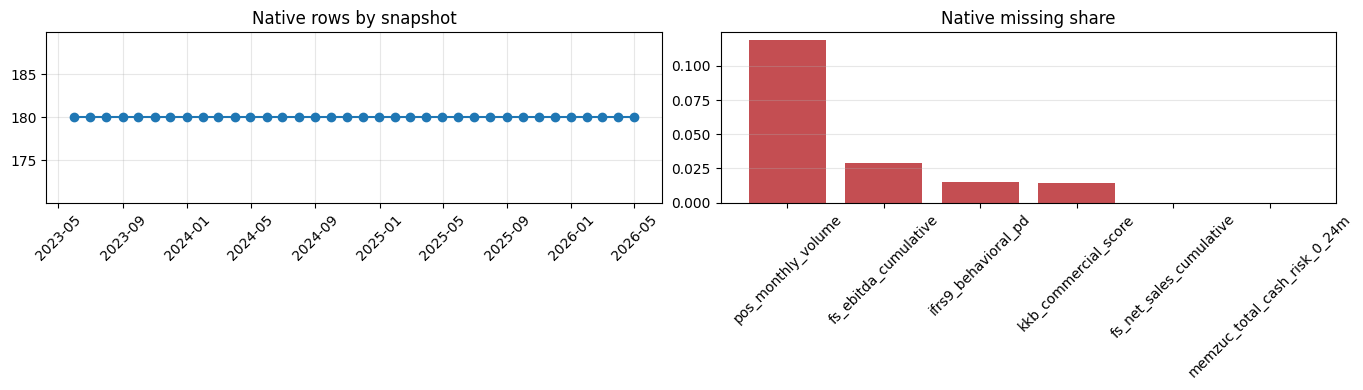

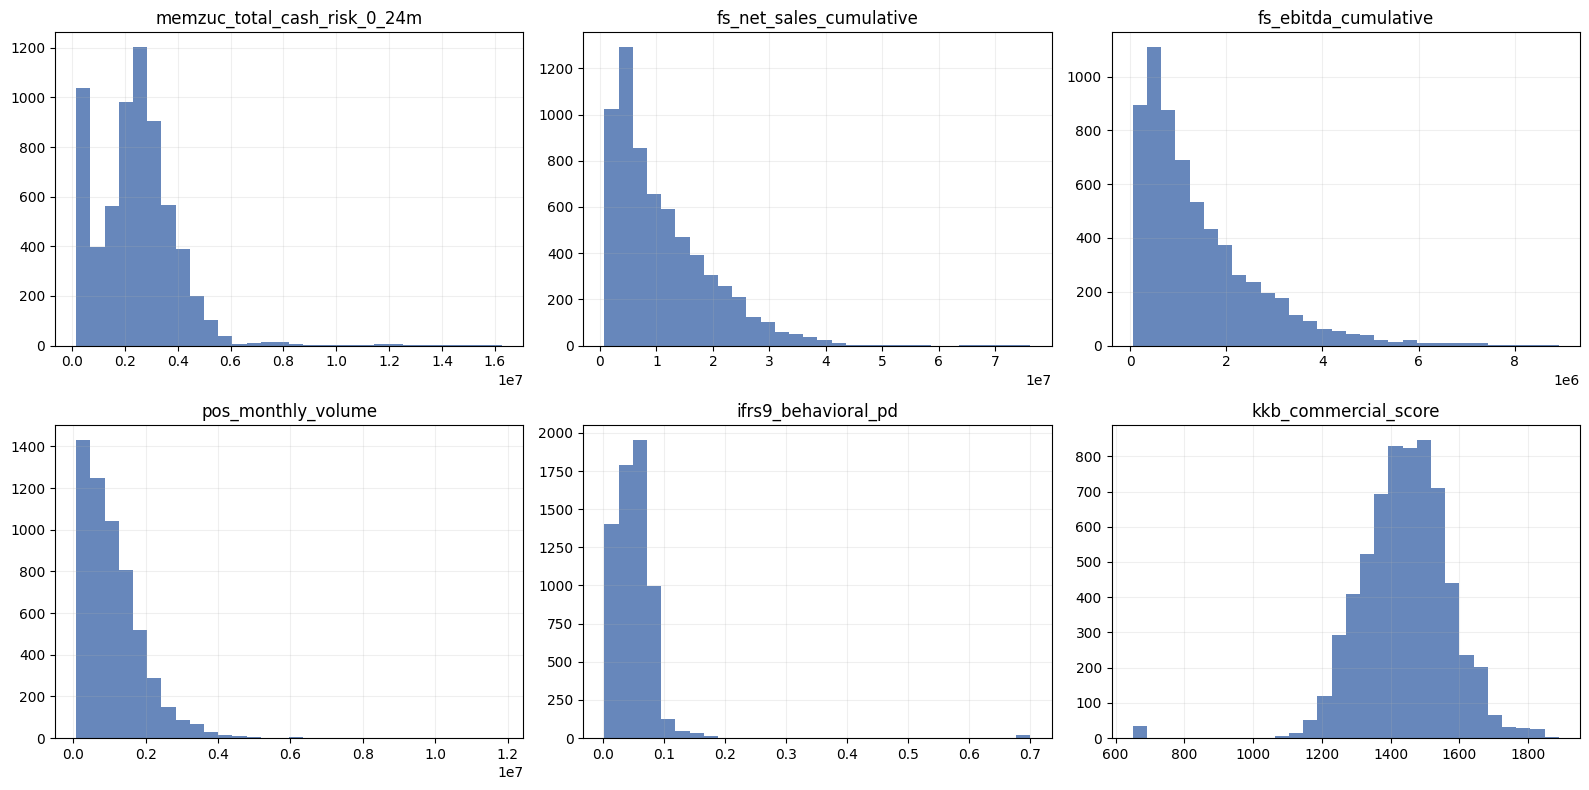

In [4]:
with OracleConnector(config, secrets) as ora:
    native_table = ora._qualified_table_name("native_features")
    native_profile = ora._read_query(
        f"""
        SELECT SNAPSHOT_DATE, CUSTOMER_ID,
               MEMZUC_TOTAL_CASH_RISK_0_24M,
               FS_NET_SALES_CUMULATIVE,
               FS_EBITDA_CUMULATIVE,
               POS_MONTHLY_VOLUME,
               IFRS9_BEHAVIORAL_PD,
               KKB_COMMERCIAL_SCORE
        FROM {native_table}
        WHERE SEGMENT = :segment_value
        """,
        {"segment_value": SEGMENT},
    )

native_profile.columns = [col.lower() for col in native_profile.columns]
native_profile["snapshot_date"] = pd.to_datetime(native_profile["snapshot_date"])
native_numeric_cols = [
    "memzuc_total_cash_risk_0_24m",
    "fs_net_sales_cumulative",
    "fs_ebitda_cumulative",
    "pos_monthly_volume",
    "ifrs9_behavioral_pd",
    "kkb_commercial_score",
]
native_missing = native_profile[native_numeric_cols].isna().mean().sort_values(ascending=False).reset_index()
native_missing.columns = ["feature", "missing_share"]
snapshot_density = native_profile.groupby("snapshot_date").agg(rows=("customer_id", "size"), customers=("customer_id", "nunique")).reset_index()

display(native_missing)
display(snapshot_density.tail(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(snapshot_density["snapshot_date"], snapshot_density["rows"], marker="o")
axes[0].set_title("Native rows by snapshot")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)
axes[1].bar(native_missing["feature"], native_missing["missing_share"], color="#C44E52")
axes[1].set_title("Native missing share")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, column in zip(axes.flatten(), native_numeric_cols):
    axis.hist(native_profile[column].dropna(), bins=30, color="#4C72B0", alpha=0.85)
    axis.set_title(column)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 2. Materialization

**What it does**
Runs the real materialization code path from the pipeline to (re)build `EWS_TO_FAZ1_INPUT`:

- `materialize_development` does a full refresh over the complete history.
- `materialize_live` refreshes only the snapshot(s) requested by live scoring.

**How to read the output**

- `enabled: True` means materialization ran. `False` means the config switch is off (see `config/materialization_rules.yaml`).
- `native_rows` should be close to section 1's `row_count`. `derived_rows` is typically smaller because the first 18 snapshots per customer are trimmed as warm-up (needed for `lag_12` features).
- `persisted_rows` equals the number of rows rewritten in `EWS_TO_FAZ1_INPUT`. A value of 0 on development means the frame was empty; on live it means today had no snapshot (expected on mid-month days).
- `quality` sub-dict contains four reports (`native_full`, `native_scope`, `derived_full`, `derived_scope`). Status `pass` / `warn` / `fail` tells whether the data-quality gate cleared. A `fail` raises `QualityGateError` and writes a debug JSON under `runtime/logs/quality/`.

In [5]:
full_materialization = safe_run(
    "materialize_development",
    materializer.materialize_development,
    SEGMENT,
)
display(pd.DataFrame([compact_dict(full_materialization)]))


materialize_development: OK


,enabled,segment,native_source_rows,native_rows,native_scope_rows,derived_rows,scoped_rows,persisted_rows,quality,snapshot_min,snapshot_max
0,True,TICARI_ORTA,6480,4660,4660,2277,2277,2277,{'native_full': {'dataset_name': 'native_full'...,2024-11-30,2026-04-30


In [6]:
single_materialization = safe_run(
    "materialize_live(single_snapshot)",
    materializer.materialize_live,
    SEGMENT,
    snapshot_date=SINGLE_SNAPSHOT,
)

display(pd.DataFrame([compact_dict(single_materialization)]))
if isinstance(single_materialization, dict) and isinstance(single_materialization.get("frame"), pd.DataFrame):
    display(single_materialization["frame"].head())


Quality detail stage=live_scoring
[WARN] native_scope (stage=live_scoring, rule_key=native)
  rows=134 unique_customers=134 snapshots=1 feature_count=24
  avg_coverage=0.994403 min_coverage=0.962687 max_outlier_share=0.015152 duplicate_keys=0
  top_missing: pos_monthly_volume=0.037313, fs_trade_receivables=0.029851, kkb_commercial_score=0.022388, ifrs9_behavioral_pd=0.022388, fs_ebitda_cumulative=0.014925
  top_outliers: fs_ebitda_cumulative=0.015152, memzuc_business_loan_risk_0_24m=0.014925, kkb_commercial_score=0.007634, bank_total_risk=0.007463, memzuc_total_cash_risk_0_24m=0.007463
  freshness::fs_last_update_date status=pass stale_fail_share=0.0 future_date_share=1.0 max_age_days=0
  warn checks:
    - row_count: observed=134 fail<1> warn<200>


Quality detail stage=live_scoring
[WARN] derived_scope (stage=live_scoring, rule_key=derived)
  rows=128 unique_customers=128 snapshots=1 feature_count=78
  avg_coverage=0.958233 min_coverage=0.65625 max_outlier_share=0.081818 duplicate_keys=0
  top_missing: pos_volume_change__self_zscore_6=0.34375, pos_volume_change__trend_slope_6=0.296875, bank_asset_average_change__self_zscore_6=0.1875, bank_asset_average_change__trend_slope_6=0.164062, bank_debt_to_ebitda__self_zscore_6=0.148438
  top_outliers: bank_debt_to_ebitda__trend_slope_6=0.081818, bank_debt_to_ebitda__delta_1=0.04878, bank_debt_to_ebitda=0.031746, bank_debt_to_ebitda__vs_population_median_delta=0.031746, kkb_indebtedness_index__trend_slope_6=0.03125
  warn checks:
    - row_count: observed=128 fail<1> warn<200>
    - min_feature_coverage: observed=0.65625 fail<0.35> warn<0.7>
    - max_outlier_share: observed=0.081818 fail<0.1> warn<0.03>


materialize_live(single_snapshot): OK


,enabled,segment,native_source_rows,native_rows,native_scope_rows,derived_rows,scoped_rows,persisted_rows,quality,snapshot_min,snapshot_max
0,True,TICARI_ORTA,6480,4660,134,2277,128,128,{'native_full': {'dataset_name': 'native_full'...,2026-04-30,2026-04-30


,customer_id,snapshot_date,segment,bank_debt_to_turnover,pos_volume_change,bank_debt_to_ebitda,trade_receivables_to_turnover,profitability_to_turnover,business_loan_vs_inflation,equity_change,...,kkb_commercial_score__population_percentile,kkb_commercial_score__vs_population_median_delta,kkb_indebtedness_index__population_percentile,kkb_indebtedness_index__vs_population_median_delta,net_sales_change__population_percentile,net_sales_change__vs_population_median_delta,memzuc_limit_utilization_increase__population_percentile,memzuc_limit_utilization_increase__vs_population_median_delta,bank_asset_average_change__population_percentile,bank_asset_average_change__vs_population_median_delta
0,TOF0001,2026-04-30,TICARI_ORTA,0.171519,0.073144,2.431903,0.462080,0.049600,-0.246028,-0.009086,...,0.503817,0.000000,0.059701,-0.323145,0.818182,0.077188,0.723881,0.085309,0.761538,0.062869
1,TOF0002,2026-04-30,TICARI_ORTA,0.089149,0.066189,1.062437,0.512995,0.029220,-0.405062,0.079882,...,0.511450,5.081523,0.686567,0.106205,0.878788,0.089142,0.059701,-0.226891,0.823077,0.084324
2,TOF0003,2026-04-30,TICARI_ORTA,0.475411,-0.300076,4.417929,0.712273,0.032914,NaN,-0.300497,...,0.022901,-269.952634,0.500000,-0.000054,0.075758,-0.180496,0.985075,0.254231,0.076923,-0.147905
3,TOF0008,2026-04-30,TICARI_ORTA,0.326691,-0.295251,4.049343,0.625617,-0.014596,0.247446,-0.333796,...,0.488550,-11.251025,0.529851,0.024323,0.030303,-0.249186,0.977612,0.250372,0.061538,-0.168827
4,TOF0009,2026-04-30,TICARI_ORTA,0.109750,NaN,0.824645,0.559016,0.085119,-0.294576,0.002060,...,0.740458,74.732311,0.343284,-0.122885,0.863636,0.088734,0.492537,-0.004187,0.961538,0.153236


## 2A. Derived Quality and Feature Coverage

**What it does**
Queries `EWS_TO_FAZ1_INPUT` for the first six base features and reports:

1. `derived_missing` - missing share per selected feature.
2. `derived_snapshot_density` - rows and unique customers per snapshot.
3. `latest_data_time` - last `DATA_TIME` stamp per snapshot (helps verify the last write time).
4. Plots: rows by snapshot + missing share + per-feature histograms.

**How to read the output**

- Missing share is expected to be non-zero for history-dependent features (`__self_zscore_6`, `__trend_slope_6`, `__population_percentile`) because of warm-up; focus on base columns (for example `bank_debt_to_turnover`).
- Missing share above 25 percent on a base column often indicates that its native source (Memzuc, KKB, FS) was incomplete for that snapshot.
- The `latest_data_time` column should be very close to the snapshot date; a large gap means the derived table was not refreshed recently.
- Histograms should be unimodal and not pathologically skewed; multi-modal shapes appearing only on recent snapshots are early drift indicators.

,feature,missing_share
0,pos_volume_change,0.045674
1,bank_debt_to_ebitda,0.027229
2,business_loan_vs_inflation,0.020641
3,trade_receivables_to_turnover,0.017567
4,bank_debt_to_turnover,0.000000
5,profitability_to_turnover,0.000000


,snapshot_date,rows,customers
6,2025-05-31,126,126
7,2025-06-30,126,126
8,2025-07-31,126,126
9,2025-08-31,126,126
10,2025-09-30,126,126
11,2025-10-31,127,127
12,2025-11-30,127,127
13,2025-12-31,127,127
14,2026-01-31,127,127
15,2026-02-28,127,127


,snapshot_date,data_time
10,2025-09-30,2026-04-27 16:06:27.619
11,2025-10-31,2026-04-27 16:06:27.619
12,2025-11-30,2026-04-27 16:06:27.619
13,2025-12-31,2026-04-27 16:06:27.619
14,2026-01-31,2026-04-27 16:06:27.619
15,2026-02-28,2026-04-27 16:06:27.619
16,2026-03-31,2026-04-27 16:06:27.619
17,2026-04-30,2026-04-27 16:06:29.599


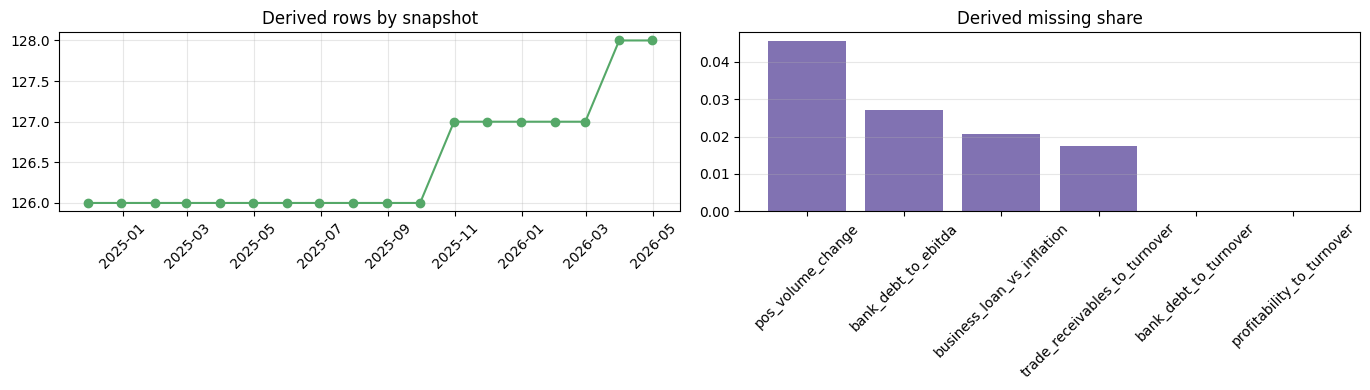

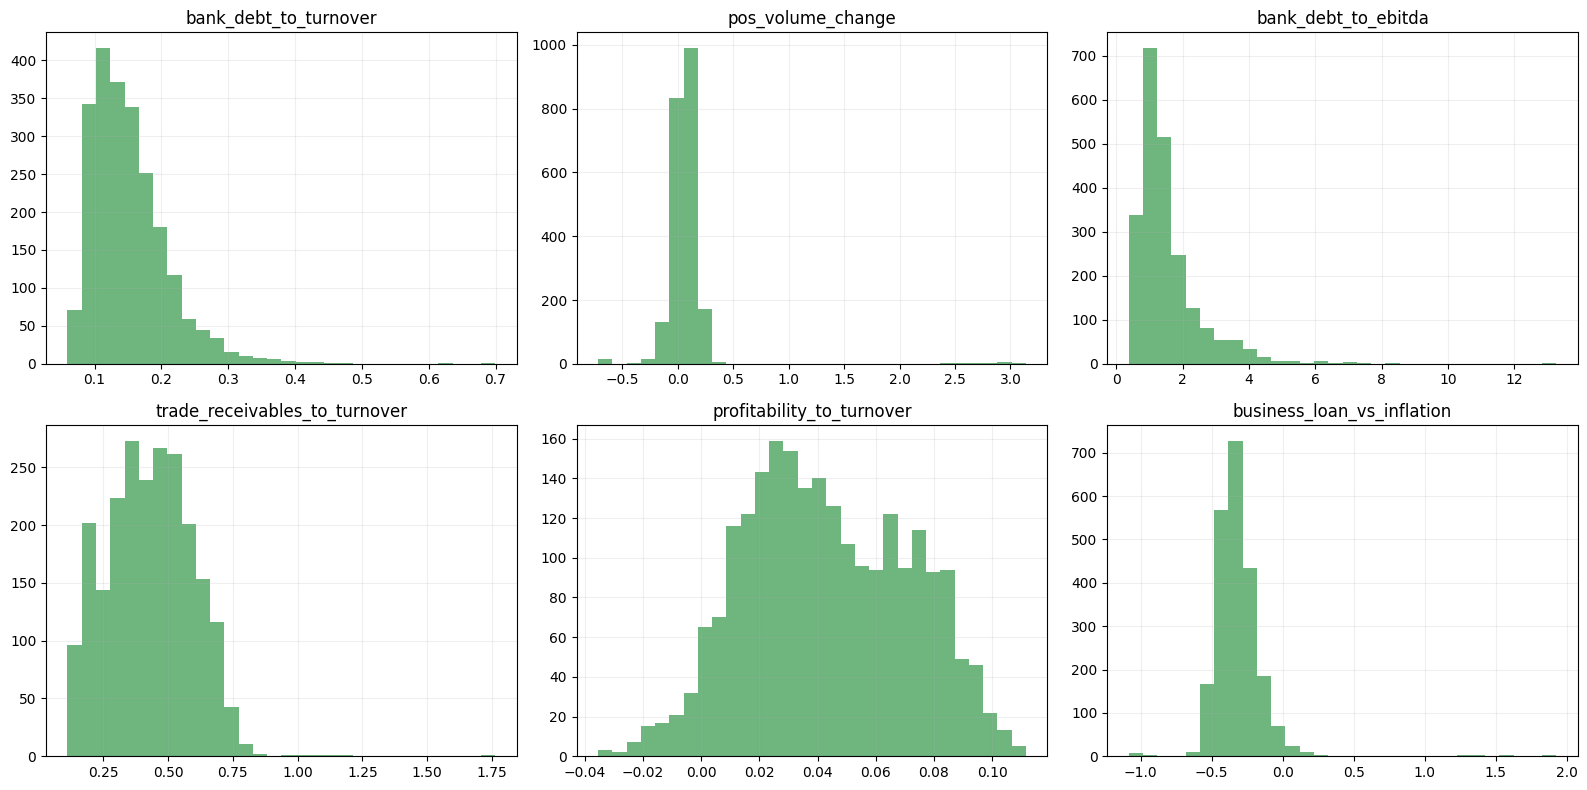

In [7]:
with OracleConnector(config, secrets) as ora:
    input_table = ora._qualified_table_name("input_features")
    selected_derived = materializer.base_feature_names[:6]
    derived_profile = ora._read_query(
        f"""
        SELECT SNAPSHOT_DATE, CUSTOMER_ID, DATA_TIME,
               {', '.join(name.upper() for name in selected_derived)}
        FROM {input_table}
        WHERE SEGMENT = :segment_value
        """,
        {"segment_value": SEGMENT},
    )

derived_profile.columns = [col.lower() for col in derived_profile.columns]
derived_profile["snapshot_date"] = pd.to_datetime(derived_profile["snapshot_date"])
derived_profile["data_time"] = pd.to_datetime(derived_profile["data_time"])
derived_missing = derived_profile[selected_derived].isna().mean().sort_values(ascending=False).reset_index()
derived_missing.columns = ["feature", "missing_share"]
derived_snapshot_density = derived_profile.groupby("snapshot_date").agg(rows=("customer_id", "size"), customers=("customer_id", "nunique")).reset_index()
latest_data_time = derived_profile.groupby("snapshot_date")["data_time"].max().reset_index().tail(8)

display(derived_missing)
display(derived_snapshot_density.tail(12))
display(latest_data_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(derived_snapshot_density["snapshot_date"], derived_snapshot_density["rows"], marker="o", color="#55A868")
axes[0].set_title("Derived rows by snapshot")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)
axes[1].bar(derived_missing["feature"], derived_missing["missing_share"], color="#8172B2")
axes[1].set_title("Derived missing share")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, column in zip(axes.flatten(), selected_derived):
    axis.hist(derived_profile[column].dropna(), bins=30, color="#55A868", alpha=0.85)
    axis.set_title(column)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 3. Development / Training / Calibration

**What it does**
Calls `manager.develop(segment=SEGMENT)`:

- Loads development frames (train / test / calibration / oot).
- Fits the ensemble (Autoencoder, Isolation Forest, Mahalanobis).
- Fits the calibrator (raw score -> percentile) if enabled.
- Registers the model as a candidate and writes the monitoring bundle and stability artefact.

**How to read the output**

- `model_version` is the candidate identifier used by subsequent sections (`tune_weights`, `evaluate_outcomes`, `promote`).
- `monitoring_path` points to `runtime/runs/<run_id>/monitoring/monitoring.json` containing input/score summaries.
- `stability_path` points to `stability.json` used in section 3A.
- `calibration_status` values:
  - `fitted` - calibration trained on enough rows; percentile mapping active.
  - `insufficient_rows` - window smaller than `calibration.min_rows`; scoring falls back to raw scores.
  - `disabled` - calibration explicitly turned off in config.
- `windows` shows the boundary of each split; a missing `oot` boundary means the OOT window is empty.

In [8]:
develop_summary = safe_run("develop", manager.develop, segment=SEGMENT)
display(pd.DataFrame([develop_summary]))


develop: OK


,model_version,segment,status,run_id,created_at,artifact_path,artifact_dir,stability_path,monitoring_path,monitoring_dir,sampling_path,feature_selection_path,windows,sampling,calibration,shadow_scoring,preprocessing,feature_selection,weighting,log_path
0,TICARI_ORTA-develop-20260427130637,TICARI_ORTA,candidate,develop-TICARI_ORTA-20260427130630-39e5b201,2026-04-27T13:06:30+00:00,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,"{'train': {'rows': 1319, 'start': '2024-11-30'...","{'train': {'window': 'train', 'status': 'disab...","{'enabled': True, 'status': 'fitted', 'version...","{'enabled': False, 'status': 'disabled', 'vers...","{'scaler_type': 'robust', 'missing_strategy': ...","{'enabled': True, 'kept_features': ['bank_debt...","{'status': 'config_default', 'source': 'config...",C:\Users\Acer\ews-anomaly-detection\runtime\ru...


## 3A. Window Split, Distribution and Stability Review

**What it does**
Reloads the development frames, prints window-level stats (rows / customers / date range), computes per-feature Kolmogorov-Smirnov tests against train, and reads the stability artefact.

**How to read the output**

- `window_summary` table should show four windows (`train`, `test`, `calibration`, `oot`). Empty `oot` is a common cause of failures in section 4.
- `window_feature_stats` shows mean, median, std, missing share per feature per window. Large mean shifts from train to oot signal upstream drift.
- KS test table: `ks_stat < 0.1` is safe, `0.1 - 0.2` is a warning, `> 0.2` implies the model is likely miscalibrated on that window.
- `stability_frame` collates ensemble-level numbers:
  - `ks_stat` - same thresholds as above but on the combined score.
  - `mean_ratio` - `reference_mean / train_mean`; ideal range 0.9 - 1.15.
  - `red_share` - share of customers in the KIRMIZI band for that window.
- The two bar charts visualize `ks_stat` and `mean_ratio` per window; a sudden spike in the OOT bar is the earliest honest signal of model decay.

,window,rows,customers,snapshot_start,snapshot_end
0,train,1319,127,2024-11-30,2025-12-31
1,test,448,124,2024-11-30,2025-12-31
2,calibration,510,128,2026-01-31,2026-04-30
3,oot,510,128,2026-01-31,2026-04-30


,window,feature,mean,median,std,missing_share
0,train,bank_debt_to_turnover,0.150817,0.141190,0.056697,0.000000
1,train,pos_volume_change,0.083372,0.066705,0.266347,0.047763
2,train,bank_debt_to_ebitda,1.513092,1.262470,0.876649,0.032600
3,train,trade_receivables_to_turnover,0.427284,0.430588,0.161458,0.012889
4,test,bank_debt_to_turnover,0.148374,0.136935,0.054643,0.000000
5,test,pos_volume_change,0.058417,0.066605,0.109900,0.024554
6,test,bank_debt_to_ebitda,1.452661,1.212651,0.851736,0.008929
7,test,trade_receivables_to_turnover,0.419367,0.426463,0.158130,0.022321
8,calibration,bank_debt_to_turnover,0.159357,0.145016,0.064482,0.000000
9,calibration,pos_volume_change,0.043150,0.044317,0.214082,0.058824


,feature,reference_window,ks_stat,ks_pvalue
0,bank_debt_to_turnover,test,0.041192,0.603303
1,pos_volume_change,test,0.036595,0.760431
2,bank_debt_to_ebitda,test,0.086532,0.013395
3,trade_receivables_to_turnover,test,0.032027,0.876302
4,bank_debt_to_turnover,calibration,0.063716,0.095819
5,pos_volume_change,calibration,0.127747,0.000021
6,bank_debt_to_ebitda,calibration,0.058795,0.161948
7,trade_receivables_to_turnover,calibration,0.055483,0.208601
8,bank_debt_to_turnover,oot,0.063716,0.095819
9,pos_volume_change,oot,0.127747,0.000021


C:\Users\Acer\AppData\Local\Temp\ipykernel_11524\2619210466.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(groups, labels=labels, vert=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_11524\2619210466.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(groups, labels=labels, vert=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_11524\2619210466.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(groups, labels=labels, vert=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_11524\2619210466.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

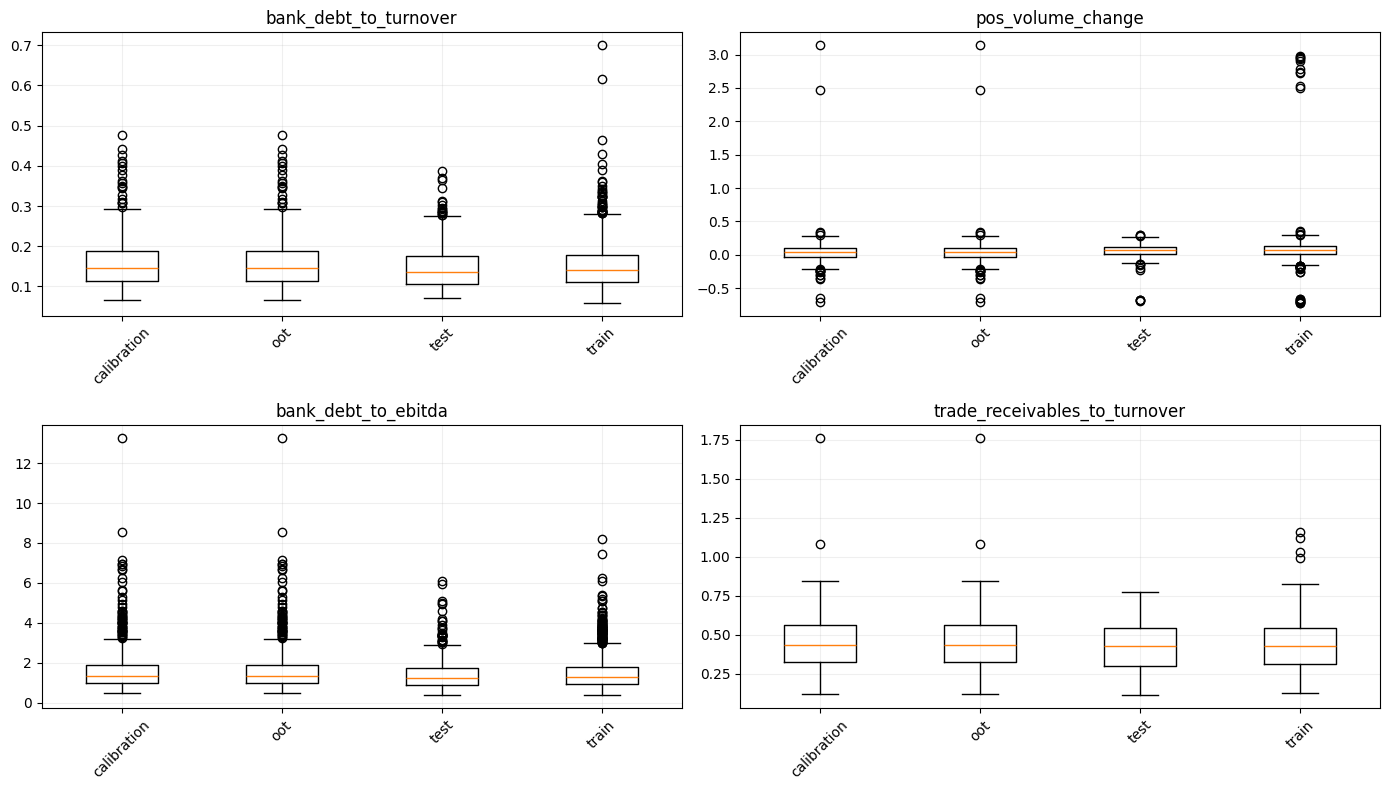

,window,train_mean,reference_mean,mean_ratio,ks_stat,ks_pvalue,red_share
0,test,45.1547,46.8700,1.0380,0.0475,0.4213,None
1,calibration,45.1547,49.9922,1.1071,0.0897,0.0050,None
2,oot,45.1547,49.9922,1.1071,0.0897,0.0050,None


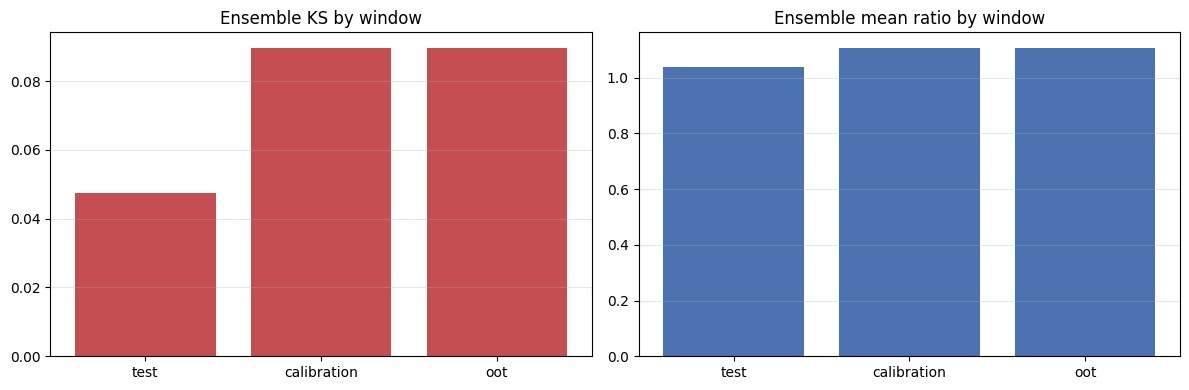

In [9]:
frames, windows = manager._load_development_frames(SEGMENT)
window_summary = pd.DataFrame(
    [
        {
            "window": name,
            "rows": len(frame),
            "customers": frame[config['pipeline']['id_column']].nunique() if not frame.empty else 0,
            "snapshot_start": pd.to_datetime(frame[config['pipeline']['time_column']]).min() if not frame.empty else pd.NaT,
            "snapshot_end": pd.to_datetime(frame[config['pipeline']['time_column']]).max() if not frame.empty else pd.NaT,
        }
        for name, frame in frames.items()
    ]
)
display(window_summary)

selected_window_features = materializer.base_feature_names[:4]
window_feature_rows = []
ks_rows = []
train_frame = frames.get('train', pd.DataFrame())
for window_name, frame in frames.items():
    if frame.empty:
        continue
    for feature_name in selected_window_features:
        feature_series = frame[feature_name]
        window_feature_rows.append(
            {
                'window': window_name,
                'feature': feature_name,
                'mean': float(feature_series.mean()),
                'median': float(feature_series.median()),
                'std': float(feature_series.std()),
                'missing_share': float(feature_series.isna().mean()),
            }
        )
        if window_name != 'train' and not train_frame.empty:
            train_values = train_frame[feature_name].dropna()
            ref_values = feature_series.dropna()
            if len(train_values) > 1 and len(ref_values) > 1:
                ks_stat, ks_pvalue = ks_2samp(train_values, ref_values)
                ks_rows.append({'feature': feature_name, 'reference_window': window_name, 'ks_stat': float(ks_stat), 'ks_pvalue': float(ks_pvalue)})

window_feature_stats = pd.DataFrame(window_feature_rows)
display(window_feature_stats)
display(pd.DataFrame(ks_rows))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for axis, feature_name in zip(axes.flatten(), selected_window_features):
    plot_frame = pd.concat(
        [frame[[feature_name]].assign(window=name) for name, frame in frames.items() if not frame.empty],
        ignore_index=True,
    )
    groups = [group[feature_name].dropna().to_numpy() for _, group in plot_frame.groupby('window')]
    labels = list(plot_frame.groupby('window').groups.keys())
    axis.boxplot(groups, labels=labels, vert=True)
    axis.set_title(feature_name)
    axis.tick_params(axis='x', rotation=45)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

stability_payload = load_json_payload(develop_summary.get('stability_path')) if isinstance(develop_summary, dict) else None
if stability_payload:
    stability_rows = []
    for window_name, payload in stability_payload.items():
        metric = payload.get('metrics', {}).get('ensemble_score', {})
        stability_rows.append(
            {
                'window': window_name,
                'train_mean': metric.get('train', {}).get('mean'),
                'reference_mean': metric.get('reference', {}).get('mean'),
                'mean_ratio': metric.get('mean_ratio'),
                'ks_stat': metric.get('ks_stat'),
                'ks_pvalue': metric.get('ks_pvalue'),
                'red_share': payload.get('ensemble_alert_share', {}).get('KIRMIZI'),
            }
        )
    stability_frame = pd.DataFrame(stability_rows)
    display(stability_frame)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(stability_frame['window'], stability_frame['ks_stat'], color='#C44E52')
    axes[0].set_title('Ensemble KS by window')
    axes[0].grid(axis='y', alpha=0.3)
    axes[1].bar(stability_frame['window'], stability_frame['mean_ratio'], color='#4C72B0')
    axes[1].set_title('Ensemble mean ratio by window')
    axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Stability payload bulunamadi.')


## 3B. Robustness Tests

**What it does**
Runs three side-by-side variants of the pipeline (preprocessing on/off, feature-selection on/off, sampling on/off) using the pipeline's own compare methods. Each comparison lands a JSON + Markdown report under `runtime/runs/<run_id>/`.

**How to read the output**

- `compare_summaries` lists the output paths. If any row has `error`, the comparison failed and the message explains why.
- `compare_metrics` flattens the supervised primary metric for each variant:
  - `baseline_*` - the simpler configuration.
  - `candidate_*` (or `routed_*`, `sampled_*`) - the richer configuration.
  - Positive deltas on precision / recall / f1 mean the extra machinery helps; near-zero deltas mean it does not add much.
- Use these numbers to decide whether preprocessing, feature selection, or sampling should be kept enabled in the live config. A small positive precision delta paired with a small OOT KS drop is usually worth keeping.

In [10]:
preprocessing_compare = safe_run('compare_preprocessing', manager.compare_preprocessing, segment=SEGMENT)
feature_selection_compare = safe_run('compare_feature_selection', manager.compare_feature_selection, segment=SEGMENT)
sampling_compare = safe_run('compare_sampling', manager.compare_sampling, segment=SEGMENT)
compare_summaries = pd.DataFrame([
    compact_dict(preprocessing_compare),
    compact_dict(feature_selection_compare),
    compact_dict(sampling_compare),
])
display(compare_summaries)

compare_frames = []
for name, summary in [('preprocessing', preprocessing_compare), ('feature_selection', feature_selection_compare), ('sampling', sampling_compare)]:
    payload = load_json_payload(summary.get('comparison_path')) if isinstance(summary, dict) else None
    if not payload:
        continue
    baseline_primary = payload.get('baseline', {}).get('outcomes', {}).get('primary', {})
    candidate_key = [key for key in ('candidate', 'routed', 'sampled') if key in payload]
    candidate_primary = payload.get(candidate_key[0], {}).get('outcomes', {}).get('primary', {}) if candidate_key else {}
    compare_frames.append(
        {
            'comparison': name,
            'baseline_precision': baseline_primary.get('precision_at_top_percent'),
            'baseline_recall': baseline_primary.get('recall_at_top_percent'),
            'baseline_f1': baseline_primary.get('f1_at_top_percent'),
            'candidate_precision': candidate_primary.get('precision_at_top_percent'),
            'candidate_recall': candidate_primary.get('recall_at_top_percent'),
            'candidate_f1': candidate_primary.get('f1_at_top_percent'),
        }
    )
compare_metrics = pd.DataFrame(compare_frames)
display(compare_metrics)


compare_preprocessing: OK


compare_feature_selection: OK


compare_sampling: OK


,segment,comparison_path,markdown_path,sample_customer_id,log_path
0,TICARI_ORTA,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,TOF0170,C:\Users\Acer\ews-anomaly-detection\runtime\ru...
1,TICARI_ORTA,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,TOF0170,C:\Users\Acer\ews-anomaly-detection\runtime\ru...
2,TICARI_ORTA,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,TOF0170,C:\Users\Acer\ews-anomaly-detection\runtime\ru...


,comparison,baseline_precision,baseline_recall,baseline_f1,candidate_precision,candidate_recall,candidate_f1
0,preprocessing,0.725490,0.284615,0.408840,NaN,NaN,NaN
1,feature_selection,0.745098,0.292308,0.419890,0.764706,0.3,0.430939
2,sampling,0.764706,0.300000,0.430939,0.764706,0.3,0.430939


## 4. Supervised Validation

**What it does**
Runs `evaluate_outcomes` (joins scored frames with `EWS_TO_FAZ1_OUTCOMES` and computes labelled metrics) and `tune_weights` (grid-searches ensemble weights on the tuning window with `apply=False`, so production weights are not overwritten).

**How to read the output**

- `evaluation_summary` includes:
  - `evaluation_path` - full JSON artefact.
  - `metrics` - dict with `primary` and `monitoring` sections. `primary` uses `label_30dpd_8w` (configurable).
- `weight_tuning_summary` includes:
  - `weight_version` and `applied` (True if the new weights replaced the defaults).
  - `validation_metrics` at the top percent threshold.
- Both payloads surface:
  - `precision_at_top_percent` - share of the top X percent flagged as positive.
  - `recall_at_top_percent` - share of actual positives captured in the top X percent.
  - `lift_at_top_percent` - precision divided by baseline rate; values above 1.5 are a good sign, close to 1.0 means the ranking is no better than random.

In [11]:
evaluation_summary = safe_run(
    "evaluate_outcomes",
    manager.evaluate_outcomes,
    segment=SEGMENT,
    model_version=develop_summary.get("model_version") if isinstance(develop_summary, dict) else None,
)
display(pd.DataFrame([evaluation_summary]))

weight_tuning_summary = safe_run(
    "tune_weights",
    manager.tune_weights,
    segment=SEGMENT,
    model_version=develop_summary.get("model_version") if isinstance(develop_summary, dict) else None,
    apply=False,
)
display(pd.DataFrame([weight_tuning_summary]))


evaluate_outcomes: OK


,segment,model_version,evaluation_path,metrics,log_path
0,TICARI_ORTA,TICARI_ORTA-develop-20260427130637,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,"{'rows': 958, 'top_n': 96, 'weights': {'autoen...",C:\Users\Acer\ews-anomaly-detection\runtime\ru...


tune_weights: OK


,segment,model_version,weight_version,applied,artifact_path,validation_metrics,log_path
0,TICARI_ORTA,TICARI_ORTA-develop-20260427130637,TICARI_ORTA-develop-20260427130637-wgt,False,C:\Users\Acer\ews-anomaly-detection\runtime\mo...,"{'rows': 510, 'top_n': 51, 'weights': {'autoen...",C:\Users\Acer\ews-anomaly-detection\runtime\ru...


## 4A. Supervised Metrics Breakdown

**What it does**
Flattens `metrics` from both the evaluation and weight-tuning payloads into clean DataFrames and draws precision / recall / f1 bar charts for each.

**How to read the output**

- `evaluation_metrics_frame` and `weight_tuning_metrics_frame` break down metrics by `metric_group` (`primary`, per-monitoring-column).
- In the primary row compare:
  - `precision_at_top_percent` against the baseline positive rate - the gap is the real-world value of the model.
  - `recall_at_top_percent` - low is expected because we only mark the top N percent; the absolute number matters less than its direction over time.
  - `f1_at_top_percent` - combined view.
- Bar charts let you eyeball whether the tuned weights clearly beat the default ensemble weights; a difference below 2-3 percent is usually noise.

,metric_group,positive_rows,baseline_rate,precision_at_top_percent,recall_at_top_percent,lift_at_top_percent,f1_at_top_percent
0,primary,199,0.207724,0.635417,0.306533,3.058941,0.413559
1,label_default_12m,96,0.100209,0.322917,0.322917,3.222439,0.322917


,metric_group,positive_rows,baseline_rate,precision_at_top_percent,recall_at_top_percent,lift_at_top_percent,f1_at_top_percent
0,primary,130,0.254902,0.745098,0.292308,2.923077,0.419890
1,label_default_12m,65,0.127451,0.470588,0.369231,3.692308,0.413793


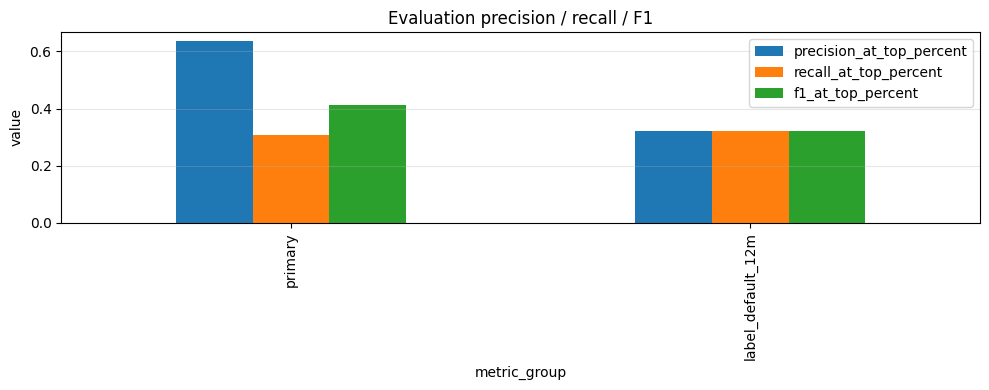

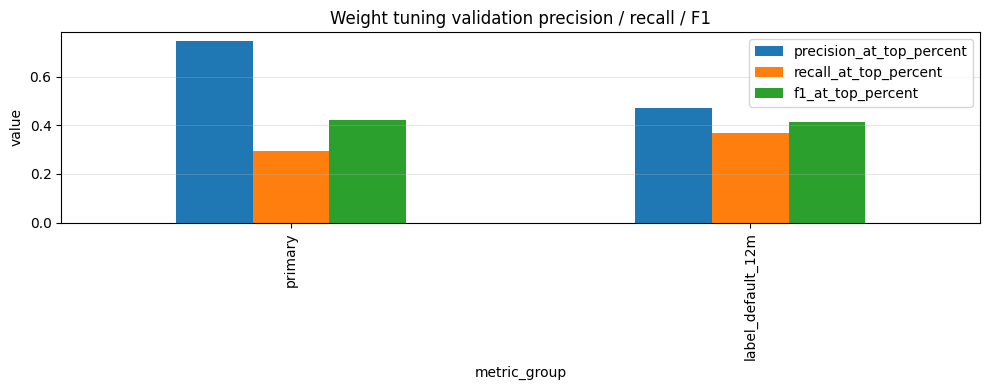

In [12]:
evaluation_metrics_frame = flatten_outcome_metrics(evaluation_summary.get('metrics', {})) if isinstance(evaluation_summary, dict) else pd.DataFrame()
weight_tuning_metrics_frame = flatten_outcome_metrics(weight_tuning_summary.get('validation_metrics', {})) if isinstance(weight_tuning_summary, dict) else pd.DataFrame()

display(evaluation_metrics_frame)
display(weight_tuning_metrics_frame)

if not evaluation_metrics_frame.empty:
    draw_metric_bar(
        evaluation_metrics_frame,
        category_column='metric_group',
        value_columns=['precision_at_top_percent', 'recall_at_top_percent', 'f1_at_top_percent'],
        title='Evaluation precision / recall / F1',
    )

if not weight_tuning_metrics_frame.empty:
    draw_metric_bar(
        weight_tuning_metrics_frame,
        category_column='metric_group',
        value_columns=['precision_at_top_percent', 'recall_at_top_percent', 'f1_at_top_percent'],
        title='Weight tuning validation precision / recall / F1',
    )


## 5. Promote and Live Scoring

**What it does**
Promotes the most recent candidate to champion and executes live scoring twice:

- Single snapshot (from `live_scoring.snapshot.selector` or an explicit date).
- Date range (four most recent snapshots, overridable via config).

Both calls go through `engine.lifecycle.LifecycleManager.score_live`, which rematerializes only the requested scope before scoring.

**How to read the output**

- `promote_summary` contains the segment, the promoted model version, and the log path.
- `single_score_summary` / `range_score_summary` include:
  - `status` - `completed`, or `skipped` if no rows existed for that scope (mid-month today() is the common skip cause).
  - `rows` - number of customers scored.
  - `monitoring_path` - per-run JSON with score and band stats.
  - `output` - summary of rows written to `EWS_TO_FAZ1_RESULTS`, `EWS_TO_FAZ1_DETAILS`, `EWS_TO_FAZ1_FEATURE_EFFECTS`.

In [13]:
promote_summary = safe_run(
    "promote",
    manager.promote,
    segment=SEGMENT,
    model_version=develop_summary.get("model_version") if isinstance(develop_summary, dict) else None,
)
display(pd.DataFrame([promote_summary]))

single_score_summary = safe_run(
    "score_live(single_snapshot)",
    manager.score_live,
    segment=SEGMENT,
    snapshot_date=SINGLE_SNAPSHOT,
)
display(pd.DataFrame([single_score_summary]))

range_score_summary = safe_run(
    "score_live(range)",
    manager.score_live,
    segment=SEGMENT,
    start_date=RANGE_START,
    end_date=RANGE_END,
)
display(pd.DataFrame([range_score_summary]))


promote: OK


,segment,promoted_model,log_path
0,TICARI_ORTA,TICARI_ORTA-develop-20260427130637,C:\Users\Acer\ews-anomaly-detection\runtime\ru...


score_live(single_snapshot): OK


,segment,snapshot_date,rows,model_version,calibration_version,weight_version,quality,health,output,monitoring_path,monitoring_dir,log_path
0,TICARI_ORTA,2026-04-30,128,TICARI_ORTA-develop-20260427130637,TICARI_ORTA-develop-20260427130637-cal,None,{'materialization': {'native_full': {'dataset_...,"{'enabled': True, 'overall_status': 'YELLOW', ...","{'backend': 'oracle', 'deleted_results': 0, 'd...",C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...


score_live(range): OK


,segment,snapshot_date,rows,model_version,calibration_version,weight_version,quality,health,output,monitoring_path,monitoring_dir,log_path
0,TICARI_ORTA,2026-04-30,510,TICARI_ORTA-develop-20260427130637,TICARI_ORTA-develop-20260427130637-cal,None,{'materialization': {'native_full': {'dataset_...,"{'enabled': True, 'overall_status': 'YELLOW', ...","{'backend': 'oracle', 'deleted_results': 256, ...",C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,C:\Users\Acer\ews-anomaly-detection\runtime\ru...


## 5A. Scored Range Validation and Label Lift

**What it does**
Joins the range-scoring output with the outcomes table, re-computes the manual top-percent metrics, and summarises the positive rate per alert band.

**How to read the output**

- `manual_top_metrics`:
  - `precision_at_top_percent` - the same metric computed directly against the Oracle results table for sanity.
  - `true_positive` / `false_positive` / `true_negative` / `false_negative` - raw cells of the top-N confusion matrix.
- `band_target` - per band, the count of customers and the mean of the target column. Expected monotonic ordering: `NORMAL < SARI < TURUNCU < KIRMIZI` positive rate. If KIRMIZI does not dominate, the calibration or weights may need attention.
- Left histogram - `anomaly_score` distributions split by label (`0`/`1`). Ideally the label=1 distribution sits clearly to the right of label=0.
- Right bar chart - positive rate per alert band; bars should rise from NORMAL to KIRMIZI.

,rows,top_n,positive_rows,baseline_rate,precision_at_top_percent,recall_at_top_percent,f1_at_top_percent,true_negative,false_positive,false_negative,true_positive
0,510,51,130,0.254902,0.764706,0.3,0.430939,368,12,91,39


,alert_band,count,positive_rate
0,KIRMIZI,40,0.800000
1,NORMAL,310,0.141935
2,SARI,90,0.300000
3,TURUNCU,70,0.385714


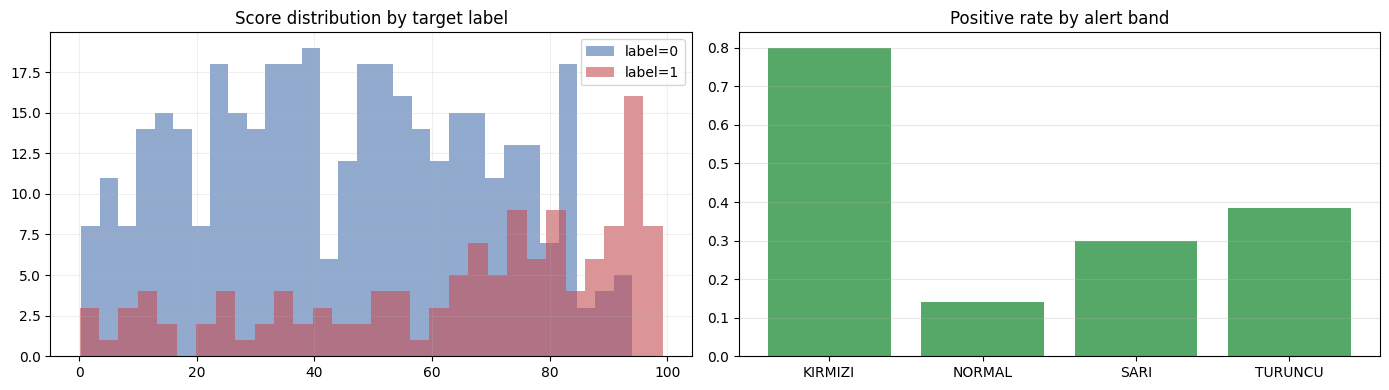

In [14]:
with OracleConnector(config, secrets) as ora:
    results_table = ora._qualified_table_name('results')
    outcomes_table = ora._qualified_table_name('outcomes')
    scored_range = ora._read_query(
        f"""
        SELECT r.CUSTOMER_ID, r.SNAPSHOT_DATE, r.ANOMALY_SCORE, r.ALERT_BAND,
               o.{TARGET_COLUMN.upper()} AS target_label
        FROM {results_table} r
        LEFT JOIN {outcomes_table} o
          ON r.CUSTOMER_ID = o.CUSTOMER_ID
         AND TRUNC(r.SNAPSHOT_DATE) = TRUNC(o.SNAPSHOT_DATE)
        WHERE r.SEGMENT = :segment_value
          AND TRUNC(r.SNAPSHOT_DATE) BETWEEN DATE '{RANGE_START}' AND DATE '{RANGE_END}'
        """,
        {'segment_value': SEGMENT},
    )

scored_range.columns = [col.lower() for col in scored_range.columns]
scored_range['snapshot_date'] = pd.to_datetime(scored_range['snapshot_date'])
scored_range['target_label'] = scored_range['target_label'].fillna(0).astype(int)
manual_top_metrics = compute_top_percent_metrics(scored_range, 'anomaly_score', 'target_label', TOP_PERCENT)
display(pd.DataFrame([manual_top_metrics]))

band_target = scored_range.groupby('alert_band')['target_label'].agg(['count', 'mean']).reset_index().rename(columns={'mean': 'positive_rate'})
display(band_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label_value, color in [(0, '#4C72B0'), (1, '#C44E52')]:
    subset = scored_range.loc[scored_range['target_label'] == label_value, 'anomaly_score']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f'label={label_value}', color=color)
axes[0].set_title('Score distribution by target label')
axes[0].legend()
axes[0].grid(alpha=0.2)
axes[1].bar(band_target['alert_band'], band_target['positive_rate'], color='#55A868')
axes[1].set_title('Positive rate by alert band')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Monitoring and Oracle Output Review

**What it does**
Reads back the scored snapshot from Oracle:

- Top 5 highest-score customers and their top reasons.
- 10 detail rows (top features explaining an alert).
- A `DATA_TIME` check (when the derived table was last rewritten for this snapshot).

**How to read the output**

- `result_sample` - shows customers with the highest `ANOMALY_SCORE` and the `REASON_1..3` columns. A single feature repeatedly owning all three reasons means the model is leaning heavily on one signal; that is something to investigate.
- `details_sample` - per-feature detail for a scored customer: `ACTUAL_VALUE` vs references, `CONTRIBUTION_PCT`, and component-level contributions (`AE_CONTRIBUTION_PCT`, `IF_CONTRIBUTION_PCT`, `MD_CONTRIBUTION_PCT`). Useful when defending an alert to business users.
- `data_time_check` - `MIN_DATA_TIME` and `MAX_DATA_TIME` should fall inside the current run window; an older timestamp means materialization did not run recently.

In [15]:
with OracleConnector(config, secrets) as ora:
    results_table = ora._qualified_table_name("results")
    details_table = ora._qualified_table_name("details")
    effects_table = ora._qualified_table_name("full_effects")
    input_table = ora._qualified_table_name("input_features")

    result_sample = ora._read_query(
        f"""
        SELECT CUSTOMER_ID, SNAPSHOT_DATE, ANOMALY_SCORE, ALERT_BAND, REASON_1, REASON_2, REASON_3
        FROM {results_table}
        WHERE TRUNC(SNAPSHOT_DATE) = DATE '{SINGLE_SNAPSHOT}'
          AND ROWNUM <= 5
        ORDER BY ANOMALY_SCORE DESC
        """
    )
    details_sample = ora._read_query(
        f"""
        SELECT CUSTOMER_ID, SNAPSHOT_DATE, FEATURE_NAME, FEATURE_LABEL,
               ACTUAL_VALUE, CUSTOMER_HISTORY_REFERENCE, POPULATION_REFERENCE,
               AE_REFERENCE, CONTRIBUTION_PCT, AE_CONTRIBUTION_PCT, IF_CONTRIBUTION_PCT, MD_CONTRIBUTION_PCT
        FROM {details_table}
        WHERE TRUNC(SNAPSHOT_DATE) = DATE '{SINGLE_SNAPSHOT}'
          AND ROWNUM <= 10
        ORDER BY FEATURE_RANK ASC
        """
    )
    data_time_check = ora._read_query(
        f"""
        SELECT TRUNC(SNAPSHOT_DATE) AS snapshot_date,
               COUNT(*) AS row_count,
               MIN(DATA_TIME) AS min_data_time,
               MAX(DATA_TIME) AS max_data_time
        FROM {input_table}
        WHERE TRUNC(SNAPSHOT_DATE) = DATE '{SINGLE_SNAPSHOT}'
        GROUP BY TRUNC(SNAPSHOT_DATE)
        """
    )

display(result_sample)
display(details_sample)
display(data_time_check)


,customer_id,snapshot_date,anomaly_score,alert_band,reason_1,reason_2,reason_3
0,TOF0085,2026-04-30,93.5,KIRMIZI,Banka Borclulugu / EBITDA\ngerceklesen: 8.53\n...,Banka Borclulugu / Ciro\ngerceklesen: 0.21\nmu...,Karlilik / Ciro\ngerceklesen: 0.00\nmusteri_ge...
1,TOF0130,2026-04-30,93.0,KIRMIZI,Isletme Borcu / Enflasyon Farki\ngerceklesen: ...,Banka Borclulugu / EBITDA\ngerceklesen: 4.50\n...,Tum Bankalar POS Hacmi Degisimi\ngerceklesen: ...
2,TOF0220,2026-04-30,92.7,KIRMIZI,Banka Borclulugu / EBITDA\ngerceklesen: 6.22\n...,Isletme Borcu / Enflasyon Farki\ngerceklesen: ...,Karlilik / Ciro\ngerceklesen: -0.02\nmusteri_g...
3,TOF0122,2026-04-30,81.4,TURUNCU,Memzuc Limit Doluluk Orani\ngerceklesen: 0.80\...,Banka Borclulugu / Ciro\ngerceklesen: 0.19\nmu...,Tum Bankalar POS Hacmi Degisimi\ngerceklesen: ...
4,TOF0129,2026-04-30,81.4,TURUNCU,KKB Ticari Kredi Notu\ngerceklesen: 650.00\nmu...,Ticari Alacak / Ciro\ngerceklesen: 0.18\nmuste...,Tum Bankalar POS Hacmi Degisimi\ngerceklesen: ...


,customer_id,snapshot_date,feature_name,feature_label,actual_value,customer_history_reference,population_reference,ae_reference,contribution_pct,ae_contribution_pct,if_contribution_pct,md_contribution_pct
0,TOF0179,2026-04-30,bank_debt_to_ebitda,Banka Borclulugu / EBITDA,2.989205,4.24,1.36,1.58,27.2,17.8,5.8,3.6
1,TOF0130,2026-04-30,business_loan_vs_inflation,Isletme Borcu / Enflasyon Farki,0.433222,-0.11,-0.35,0.26,12.6,6.8,2.7,3.0
2,TOF0089,2026-04-30,kkb_indebtedness_index,KKB Ticari Borcluluk Endeksi,1.010219,0.90,0.68,0.78,15.8,7.7,6.7,1.5
3,TOF0220,2026-04-30,bank_debt_to_ebitda,Banka Borclulugu / EBITDA,6.223997,4.94,1.36,3.27,32.2,20.6,5.9,5.7
4,TOF0130,2026-04-30,bank_debt_to_ebitda,Banka Borclulugu / EBITDA,4.498643,2.47,1.36,4.38,11.9,3.8,5.5,2.5
5,TOF0220,2026-04-30,business_loan_vs_inflation,Isletme Borcu / Enflasyon Farki,0.029686,-0.24,-0.35,-0.01,15.2,6.3,4.7,4.2
6,TOF0089,2026-04-30,business_loan_vs_inflation,Isletme Borcu / Enflasyon Farki,0.178412,-0.45,-0.35,0.09,15.6,1.7,6.0,8.0
7,TOF0089,2026-04-30,bank_debt_to_ebitda,Banka Borclulugu / EBITDA,0.727470,0.57,1.36,1.93,13.4,7.6,3.7,2.0
8,TOF0130,2026-04-30,pos_volume_change,Tum Bankalar POS Hacmi Degisimi,-0.358333,-0.14,0.04,-0.27,11.1,5.6,3.8,1.7
9,TOF0220,2026-04-30,profitability_to_turnover,Karlilik / Ciro,-0.019603,0.00,0.04,0.01,10.4,4.2,5.4,0.8


,snapshot_date,row_count,min_data_time,max_data_time
0,2026-04-30,128,2026-04-27 16:08:52.553,2026-04-27 16:08:52.553


In [16]:
monitoring_path = single_score_summary.get("monitoring_path") if isinstance(single_score_summary, dict) else None
if monitoring_path:
    monitoring_payload = json.loads(Path(monitoring_path).read_text(encoding="utf-8"))
    display(pd.DataFrame([monitoring_payload.get("scores", {})]))
    display(pd.DataFrame([monitoring_payload.get("input", {})]))
    health_payload = monitoring_payload.get("health", {})
    display(pd.DataFrame([{
        "health_overall": health_payload.get("overall_status"),
        "health_green": (health_payload.get("counts") or {}).get("GREEN", 0),
        "health_yellow": (health_payload.get("counts") or {}).get("YELLOW", 0),
        "health_red": (health_payload.get("counts") or {}).get("RED", 0),
        "health_skipped": (health_payload.get("counts") or {}).get("SKIPPED", 0),
    }]))
else:
    print("Monitoring payload bulunamadi.")


,rows,band_share,anomaly_score,score_buckets,ae_score,if_score,md_score,ae_raw,if_raw,md_raw
0,128,"{'NORMAL': 0.6016, 'SARI': 0.1484, 'TURUNCU': ...","{'mean': 51.6562, 'median': 51.55, 'p95': 94.6...","{'000_010': 0.046875, '010_020': 0.109375, '02...","{'mean': 51.7176, 'median': 53.375, 'p95': 96....","{'mean': 51.914, 'median': 52.02, 'p95': 97.31...","{'mean': 51.0584, 'median': 50.27, 'p95': 96.7...","{'mean': 30.389, 'median': 26.6336, 'p95': 58....","{'mean': -0.0268, 'median': -0.0407, 'p95': 0....","{'mean': 7.5862, 'median': 7.0693, 'p95': 11.2..."


,rows,unique_customers,snapshots,start,end,avg_feature_missing_ratio,top_missing_features
0,128,128,1,2026-04-30,2026-04-30,0.041767,"{'pos_volume_change__self_zscore_6': 0.34375, ..."


,health_overall,health_green,health_yellow,health_red,health_skipped
0,YELLOW,3,3,0,3


## 6A. Monitoring Visualization

**What it does**
Reads the per-run `monitoring.json` produced by the previous score-live call and plots two quick summaries:

- Alert band share bar chart.
- Top missing share of features seen in the scored input.

**How to read the output**

- Band share bars - KIRMIZI between 2 - 10 percent is typical; values above 20 percent indicate the model is over-alerting or data quality dropped.
- Top missing bars - for a healthy live run, these should mostly be the history-dependent columns (`__self_zscore_6`, `__trend_slope_6`). If a base column (like `bank_debt_to_turnover`) appears here the upstream ETL was incomplete.

,alert_band,share
0,NORMAL,0.6016
1,SARI,0.1484
2,TURUNCU,0.1562
3,KIRMIZI,0.0938


,feature,missing_share
0,pos_volume_change__self_zscore_6,0.343750
1,pos_volume_change__trend_slope_6,0.296875
2,bank_asset_average_change__self_zscore_6,0.187500
3,bank_asset_average_change__trend_slope_6,0.164062
4,bank_debt_to_ebitda__self_zscore_6,0.148438


,key,status,value,message
0,quality_native_scope,YELLOW,warn,enum=warn
1,quality_derived_scope,YELLOW,warn,enum=warn
2,avg_missing_ratio,GREEN,0.041767,value<=0.05
3,band_kirmizi,GREEN,0.0938,0.02<=0.0938<=0.12
4,score_psi_vs_prev,YELLOW,0.184378,value<=0.2
5,stability_oot_ks,SKIPPED,None,missing_value
6,stability_oot_mean_ratio,SKIPPED,None,missing_value
7,calibration_monotonic,GREEN,True,enum=true
8,supervised_precision,SKIPPED,None,missing_value


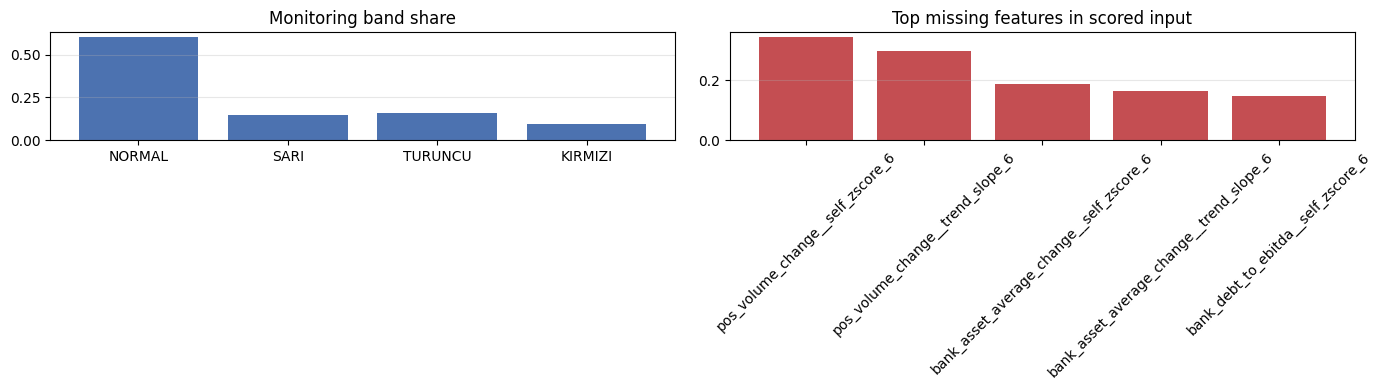

In [17]:
if monitoring_path:
    score_payload = monitoring_payload.get('scores', {})
    input_payload = monitoring_payload.get('input', {})
    health_payload = monitoring_payload.get('health', {})
    band_frame = pd.DataFrame(
        [{'alert_band': key, 'share': value} for key, value in (score_payload.get('band_share') or {}).items()]
    )
    missing_frame = pd.DataFrame(
        [{'feature': key, 'missing_share': value} for key, value in (input_payload.get('top_missing_features') or {}).items()]
    )
    health_frame = pd.DataFrame((health_payload.get('checks') or []))
    display(band_frame)
    display(missing_frame)
    display(health_frame[['key', 'status', 'value', 'message']] if not health_frame.empty else health_frame)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if not band_frame.empty:
        axes[0].bar(band_frame['alert_band'], band_frame['share'], color='#4C72B0')
        axes[0].set_title('Monitoring band share')
        axes[0].grid(axis='y', alpha=0.3)
    if not missing_frame.empty:
        axes[1].bar(missing_frame['feature'], missing_frame['missing_share'], color='#C44E52')
        axes[1].set_title('Top missing features in scored input')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Monitoring payload bulunamadi.')


## 7A. Monitor History Trend (Oracle)

**What it does**
Reads the last 50 rows from `EWS_TO_FAZ1_MONITOR_HISTORY` (persistent run-level metrics, one row per develop / tune / evaluate / score-live), shows:

1. A raw table of the most recent runs.
2. Four trend plots by run type.
3. A "latest value per run type" summary table.

**How to read the output**

- Recent-runs table - quickly spot any `status` that is not `completed`. `RUN_ID` encodes the run type + segment + timestamp.
- Run type counts - sanity check that the expected run types actually populate the table (every batch should add at least one `score-live`).
- Trend plots (top row uses `score-live` only):
  - **Band share**: KIRMIZI + TURUNCU shares over time. A sudden jump is either an improved signal or a data break - cross-check with section 1A.
  - **Anomaly score stats**: `mean` and `p99`. `p99` > 99 with a tight mean means the distribution is collapsing toward the top - a calibration symptom.
- Trend plots (bottom row):
  - **Develop stability**: ensemble OOT `ks_stat` (safe < 0.1) and `mean_ratio` (ideal 0.9 - 1.15). Drift shows up here first.
  - **Supervised**: `precision@top%` and `lift@top%` across tune-weights and evaluate-outcomes runs. Watch for lift trending toward 1.0.
- Latest-per-type table - single snapshot of current health:
  - `score-live` row shows `score_p99`, `band_kirmizi`, `band_persistence_kirmizi`, `score_psi_vs_prev`, `dominant_reason_feature`.
  - `develop` row shows stability KS per window, calibration rows, monotonic flag.
  - `tune-weights` / `evaluate-outcomes` rows show the latest supervised precision / lift and the active weight mix.

**Health thresholds in one glance**

| metric | green | yellow | red |
|---|---|---|---|
| `band_kirmizi` | 0.02 - 0.10 | 0.10 - 0.20 | > 0.20 or 0 |
| `band_persistence_kirmizi` | > 0.60 | 0.40 - 0.60 | < 0.40 |
| `score_psi_vs_prev` | < 0.1 | 0.1 - 0.25 | > 0.25 |
| `stability_oot_ks` | < 0.10 | 0.10 - 0.20 | > 0.20 |
| `stability_oot_mean_ratio` | 0.90 - 1.15 | 0.85 - 1.20 | outside |
| `supervised_precision` | >= baseline * 1.5 | baseline * 1.1 - 1.5 | <= baseline * 1.1 |
| `supervised_lift` | >= 1.5 | 1.1 - 1.5 | <= 1.1 |
| `dominant_reason_share` | < 0.35 | 0.35 - 0.55 | > 0.55 (single feature dominates) |
| `freshness_max_age_days` | <= 120 | 120 - 220 | > 220 |
| `calibration_monotonic` | 1 | - | 0 or NULL while `calibration_rows` > 0 |

In [18]:
with OracleConnector(config, secrets) as ora:
    hist_table = ora._qualified_table_name('monitor_history')
    monitor_history = ora._read_query(
        f"""
        SELECT *
        FROM {hist_table}
        WHERE SEGMENT = :segment_value
        ORDER BY FINISHED_AT DESC
        FETCH FIRST 50 ROWS ONLY
        """,
        {'segment_value': SEGMENT},
    )

monitor_history.columns = [col.lower() for col in monitor_history.columns]
monitor_history['finished_at'] = pd.to_datetime(monitor_history['finished_at'])
monitor_history = monitor_history.sort_values('finished_at', ascending=False).reset_index(drop=True)
display(monitor_history.head(20))
display(monitor_history['run_type'].value_counts().rename_axis('run_type').reset_index(name='run_count'))

,run_id,run_type,segment,status,started_at,finished_at,duration_seconds,model_version,scope_snapshot,scope_start,...,dominant_reason_feature,dominant_reason_share,health_overall,health_green_count,health_yellow_count,health_red_count,health_skipped_count,result_row_count,monitoring_path,created_at
0,score-live-TICARI_ORTA-20260427130850-d1533fca,score-live,TICARI_ORTA,completed,2026-04-27 13:08:50,2026-04-27 13:08:58,8.0,TICARI_ORTA-develop-20260427130637,2026-04-30,2026-01-31,...,bank_debt_to_ebitda,0.1216,YELLOW,5,1,0,3,510.0,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,2026-04-27 16:08:58.683
1,score-live-TICARI_ORTA-20260427130844-2a4f3fd3,score-live,TICARI_ORTA,completed,2026-04-27 13:08:44,2026-04-27 13:08:49,5.0,TICARI_ORTA-develop-20260427130637,2026-04-30,NaT,...,bank_debt_to_ebitda,0.1484,YELLOW,3,3,0,3,128.0,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,2026-04-27 16:08:50.058
2,tune-weights-TICARI_ORTA-20260427130834-7872caaa,tune-weights,TICARI_ORTA,completed,2026-04-27 13:08:34,2026-04-27 13:08:44,10.0,TICARI_ORTA-develop-20260427130637,NaT,NaT,...,NaN,NaN,NaN,0,0,0,0,NaN,NaN,2026-04-27 16:08:44.204
3,evaluate-outcomes-TICARI_ORTA-20260427130826-f...,evaluate-outcomes,TICARI_ORTA,completed,2026-04-27 13:08:26,2026-04-27 13:08:34,8.0,TICARI_ORTA-develop-20260427130637,NaT,NaT,...,NaN,NaN,NaN,0,0,0,0,NaN,NaN,2026-04-27 16:08:34.379
4,develop-TICARI_ORTA-20260427130630-39e5b201,develop,TICARI_ORTA,completed,2026-04-27 13:06:30,2026-04-27 13:06:55,25.0,TICARI_ORTA-develop-20260427130637,NaT,NaT,...,NaN,NaN,GREEN,7,0,0,2,NaN,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,2026-04-27 16:06:55.537
5,evaluate-outcomes-TICARI_ORTA-20260427125657-3...,evaluate-outcomes,TICARI_ORTA,completed,2026-04-27 12:56:57,2026-04-27 12:57:06,9.0,TICARI_ORTA-challenger-20260427125626,NaT,NaT,...,NaN,NaN,NaN,0,0,0,0,NaN,NaN,2026-04-27 15:57:06.943
6,tune-weights-TICARI_ORTA-20260427125646-7c0a8a78,tune-weights,TICARI_ORTA,completed,2026-04-27 12:56:46,2026-04-27 12:56:56,10.0,TICARI_ORTA-challenger-20260427125626,NaT,NaT,...,NaN,NaN,NaN,0,0,0,0,NaN,NaN,2026-04-27 15:56:56.963
7,retrain-TICARI_ORTA-20260427125616-3ec03102,retrain,TICARI_ORTA,completed,2026-04-27 12:56:16,2026-04-27 12:56:46,30.0,TICARI_ORTA-challenger-20260427125626,NaT,NaT,...,NaN,NaN,GREEN,7,0,0,2,NaN,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,2026-04-27 15:56:46.244
8,score-live-TICARI_ORTA-20260427125611-b62ea204,score-live,TICARI_ORTA,completed,2026-04-27 12:56:11,2026-04-27 12:56:16,5.0,TICARI_ORTA-develop-20260422164453,2026-03-31,NaT,...,trade_receivables_to_turnover,0.1328,YELLOW,3,2,0,4,128.0,C:\Users\Acer\ews-anomaly-detection\runtime\ru...,2026-04-27 15:56:16.867


,run_type,run_count
0,score-live,3
1,tune-weights,2
2,evaluate-outcomes,2
3,develop,1
4,retrain,1


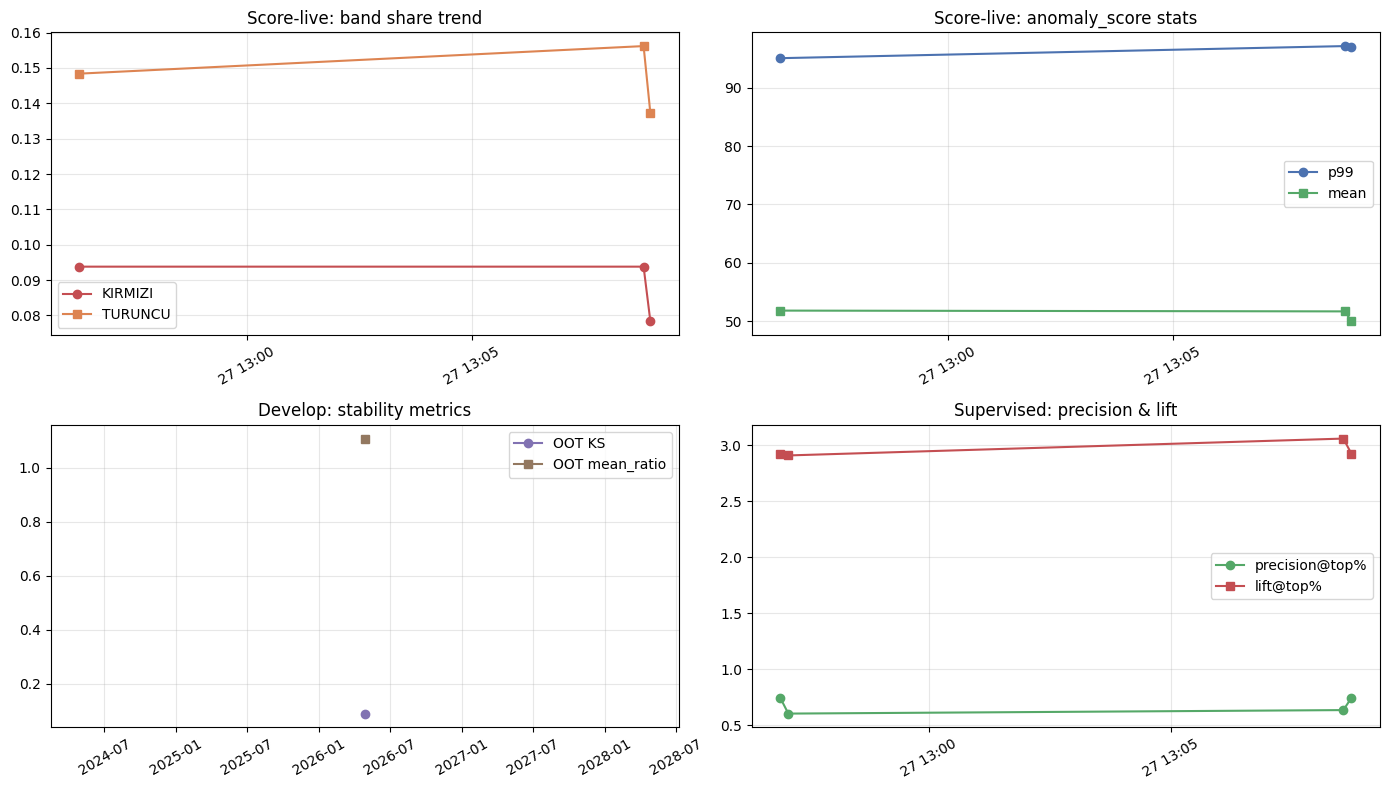

In [19]:
if monitor_history.empty:
    print('Monitor history bos.')
else:
    trend = monitor_history.sort_values('finished_at')
    score_trend = trend[trend['run_type'] == 'score-live']
    develop_trend = trend[trend['run_type'] == 'develop']
    supervised_trend = trend[trend['run_type'].isin(['evaluate-outcomes', 'tune-weights'])]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    if not score_trend.empty:
        axes[0, 0].plot(score_trend['finished_at'], score_trend['band_kirmizi'], marker='o', color='#C44E52', label='KIRMIZI')
        axes[0, 0].plot(score_trend['finished_at'], score_trend['band_turuncu'], marker='s', color='#DD8452', label='TURUNCU')
        axes[0, 0].set_title('Score-live: band share trend')
        axes[0, 0].legend()
        axes[0, 0].tick_params(axis='x', rotation=30)
        axes[0, 0].grid(alpha=0.3)
    else:
        axes[0, 0].set_title('Score-live: (no rows)')

    if not score_trend.empty:
        axes[0, 1].plot(score_trend['finished_at'], score_trend['score_p99'], marker='o', color='#4C72B0', label='p99')
        axes[0, 1].plot(score_trend['finished_at'], score_trend['score_mean'], marker='s', color='#55A868', label='mean')
        axes[0, 1].set_title('Score-live: anomaly_score stats')
        axes[0, 1].legend()
        axes[0, 1].tick_params(axis='x', rotation=30)
        axes[0, 1].grid(alpha=0.3)
    else:
        axes[0, 1].set_title('Score-live: (no rows)')

    if not develop_trend.empty:
        axes[1, 0].plot(develop_trend['finished_at'], develop_trend['stability_oot_ks'], marker='o', color='#8172B2', label='OOT KS')
        axes[1, 0].plot(develop_trend['finished_at'], develop_trend['stability_oot_mean_ratio'], marker='s', color='#937860', label='OOT mean_ratio')
        axes[1, 0].set_title('Develop: stability metrics')
        axes[1, 0].legend()
        axes[1, 0].tick_params(axis='x', rotation=30)
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].set_title('Develop: (no rows)')

    if not supervised_trend.empty:
        axes[1, 1].plot(supervised_trend['finished_at'], supervised_trend['supervised_precision'], marker='o', color='#55A868', label='precision@top%')
        axes[1, 1].plot(supervised_trend['finished_at'], supervised_trend['supervised_lift'], marker='s', color='#C44E52', label='lift@top%')
        axes[1, 1].set_title('Supervised: precision & lift')
        axes[1, 1].legend()
        axes[1, 1].tick_params(axis='x', rotation=30)
        axes[1, 1].grid(alpha=0.3)
    else:
        axes[1, 1].set_title('Supervised: (no rows)')

    plt.tight_layout()
    plt.show()

In [20]:
if monitor_history.empty:
    print('Monitor history bos, run tipi bazinda ozet uretilmedi.')
else:
    latest_per_type = (
        monitor_history.sort_values('finished_at', ascending=False)
        .groupby('run_type', as_index=False)
        .first()
    )
    display_columns = [
        'run_type', 'finished_at', 'model_version', 'status',
        'input_rows', 'band_kirmizi', 'score_p99',
        'quality_native_full', 'quality_derived_scope',
        'stability_oot_ks', 'stability_oot_mean_ratio',
        'supervised_precision', 'supervised_lift',
        'weight_ae', 'weight_if', 'weight_md',
    ]
    present = [col for col in display_columns if col in latest_per_type.columns]
    summary_frame = latest_per_type[present].copy()
    for col in summary_frame.columns:
        if summary_frame[col].dtype == object:
            summary_frame[col] = summary_frame[col].fillna('-')
    display(summary_frame)

,run_type,finished_at,model_version,status,input_rows,band_kirmizi,score_p99,quality_native_full,quality_derived_scope,stability_oot_ks,stability_oot_mean_ratio,supervised_precision,supervised_lift,weight_ae,weight_if,weight_md
0,develop,2026-04-27 13:06:55,TICARI_ORTA-develop-20260427130637,completed,510.0,NaN,NaN,PASS,PASS,0.0897,1.1071,NaN,NaN,NaN,NaN,NaN
1,evaluate-outcomes,2026-04-27 13:08:34,TICARI_ORTA-develop-20260427130637,completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.635417,3.058941,NaN,NaN,NaN
2,retrain,2026-04-27 12:56:46,TICARI_ORTA-challenger-20260427125626,completed,510.0,NaN,NaN,PASS,PASS,0.0897,1.1071,NaN,NaN,NaN,NaN,NaN
3,score-live,2026-04-27 13:08:58,TICARI_ORTA-develop-20260427130637,completed,510.0,0.0784,97.064,PASS,WARN,NaN,NaN,NaN,NaN,0.45,0.35,0.2
4,tune-weights,2026-04-27 13:08:44,TICARI_ORTA-develop-20260427130637,completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.745098,2.923077,0.30,0.30,0.4


## 7. Notes

- Native tablo ayni contract ile geldiginde notebook tekrar kullanilabilir.
- Derived/input rematerialization score cagrisi icinde otomatik yapilir.
- Single-date score ayni snapshot icin tekrar kosarsa input tablosundaki `DATA_TIME` guncellenir.
- Range scoring output tablolarinda ilgili tarih araligini replace eder.
- Scheduler bu notebook icinden degil, dis orchestration araci uzerinden tetiklenmelidir.
- Sorun giderme: bir hucre hata verirse `runtime/logs/` altindaki ilgili run log'una ve (quality fail ise) `runtime/logs/quality/` altindaki dump JSON dosyasina bakin. Tum run meta + score trend bilgisi Oracle `EWS_TO_FAZ1_MONITOR_HISTORY` tablosundan da okunabilir.